In [ ]:
!apt-get -qq install -y libsm6 libxext6 && pip install -q -U opencv-python

Mounted at /content/drive


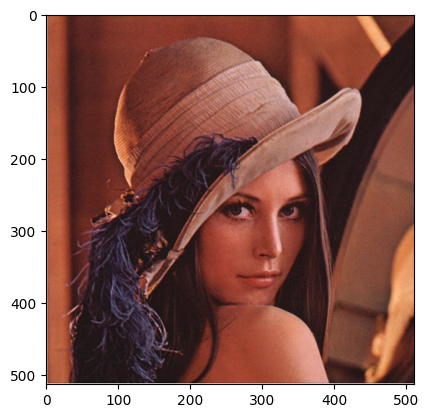

(dtype('uint8'), 3, (514, 512, 3), 789504)

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

#Пример 1
"""
Следующий пример показывает один из способов считывания
изображения с помощью OpenCV в Numpy-массив. Дополнительно
выполняется визуализация изображения с помощью библиотеки
matplotlib и вывод основных параметров массива.
"""
img = cv2.imread('/content/drive/MyDrive/Test/TestImg.jpg', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()
img.dtype, img.ndim, img.shape, img.size

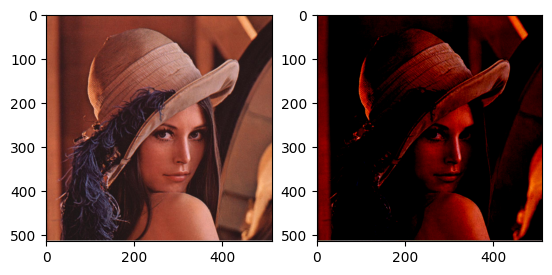

Original image: 80.38185620338845 53.021287575598556
Normed   image: -0.3695540689930317 0.4158532358870474


In [2]:
#Создание нормализации картинки, где ax = [-1;1]
"""
В данном примере показано выполнение базовых математических операций
над массивом на примере нормализации изображения (чтобы значения его
пикселей были в диапазоне [-1, 1]), с помощью операций агрегирования
считается среднее элементов массива и стандартное отклонение.
"""
img_normed = img / 127.5 - 1.0
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img)
ax[1].imshow(img_normed)
plt.show()
print("Original image:", img.mean(), img.std())
print("Normed   image:", img_normed.mean(), img_normed.std())

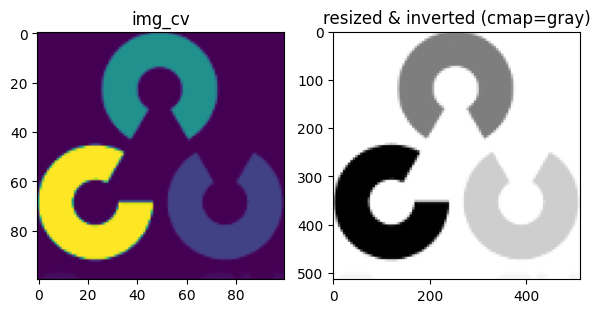

img_cv             shape: (100, 100)
resized & inverted shape: (514, 512)


In [3]:
#Создание негатива
"""
Выполняется считывание второго изображения в полутоновом формате и
resize (изменение размера изображения), чтобы размер картинки был
идентичен первой. При визуализации используются разные Color Maps.
"""
img_cv = cv2.imread('/content/drive/MyDrive/Test/opencv.png', cv2.IMREAD_GRAYSCALE)

h, w = img.shape[:2]

img_cv_resized = cv2.resize(img_cv, (w, h), interpolation=cv2.INTER_AREA)
img_cv_inv = 255 - img_cv_resized

_, ax = plt.subplots(1, 2, figsize=(7, 4))
ax[0].imshow(img_cv)
ax[1].imshow(img_cv_inv, cmap='gray')
ax[0].set_title('img_cv')
ax[1].set_title('resized & inverted (cmap=gray)')
plt.show()

print("img_cv             shape:", img_cv.shape)
print("resized & inverted shape:", img_cv_resized.shape)

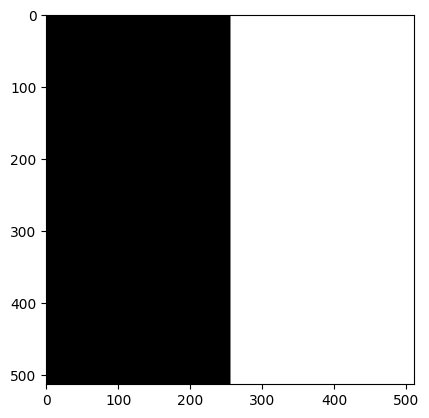

0 255


In [5]:
#Создание маски
"""
 В данном примере рассмотрен способ получения Numpy-массива
(одноканального изображения) того же размера, что и img, где по
горизонтали левая половина заполнена нулями, а правая имеет
значение 255.
"""
mask = np.zeros(img.shape, dtype='uint8')
width = img_cv_inv.shape[1]
mask[:, width//2:] = 255
plt.imshow(mask)
plt.show()
print(mask.min(), mask.max())

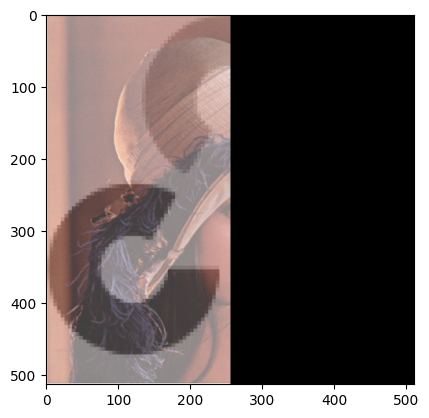

In [15]:
#комбинирование изображений + маскирование
"""
В примере показаны базовые математические операции с участием двух
массивов. Используя изображения img и img_cv_inv, выполняется
сведение двух изображений с коэффициентом 0.5. Дополнительно
рассмотрено применение операции маскирования с помощью функции
OpenCV.
"""
lam = 0.5
img_composed = img.copy()
img_composed = lam * img + (1 - lam) * img_cv_inv[..., np.newaxis]
np.putmask(img_composed, mask=mask, values=0)
plt.imshow(img_composed.astype('uint8'))
plt.show()

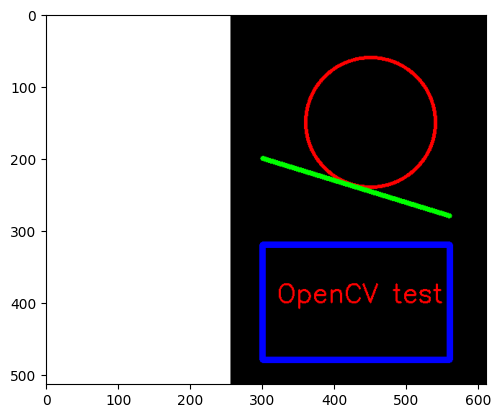

In [16]:
img_draw = cv2.copyMakeBorder(img_composed, 0, 0, 0, 100, cv2.BORDER_CONSTANT)
cv2.circle(img_draw, (450, 150), 90, (255, 0, 0), 3)
cv2.line(img_draw, (300, 200), (560, 280), (0, 255, 0), 5)
cv2.rectangle(img_draw, (300, 320), (560, 480), (0, 0, 255), 7)
cv2.putText(img_draw, 'OpenCV test', (320, 400), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 2, cv2.LINE_AA)
plt.imshow(img_draw)
plt.show()